<a href="https://colab.research.google.com/github/Cami87029i/Inteligencia-Artificial-1/blob/main/Inteligencia-Artificial-1/Laboratorios/Laboratorio3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize
%matplotlib inline

In [8]:
data = pd.read_csv('/content/drive/MyDrive/IA/slice_localization_data.csv')
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
print(X)
print(y)


[[ 0.        0.        0.       ...  0.       -0.25     -0.25    ]
 [ 0.        0.        0.       ...  0.       -0.25     -0.25    ]
 [ 0.        0.        0.       ...  0.       -0.25     -0.25    ]
 ...
 [96.        0.612313  0.       ...  0.        0.        0.      ]
 [96.        0.634921  0.904555 ...  0.       -0.25     -0.25    ]
 [96.        0.654321  0.891021 ...  0.       -0.25     -0.25    ]]
[21.803851 21.745726 21.6876   ... 27.945721 14.582997 14.498955]


In [17]:
# Binarizacion de la variable objetivo
# Clase 1: corte en la mitad superior del cuerpo (posicion > 50)
# Clase 0: corte en la mitad inferior del cuerpo (posicion <= 50)
y = (y > 50).astype(int)
print(y)

[0 0 0 ... 0 0 0]


Division del dataset: Se usa el 80% de los datos para entrenar el modelo y 20% para probar. Los datos de prueba no se toman en cuenta en el entrenamiento.

In [18]:
# Division 80% entrenamiento / 20% prueba
np.random.seed(42)
m_total  = X.shape[0]
indices  = np.random.permutation(m_total)
m_train  = int(0.8 * m_total)

train_idx = indices[:m_train]
test_idx  = indices[m_train:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print('Ejemplos de entrenamiento (80%): {:d}'.format(X_train.shape[0]))
print('Ejemplos de prueba        (20%): {:d}'.format(X_test.shape[0]))

Ejemplos de entrenamiento (80%): 42800
Ejemplos de prueba        (20%): 10700


Visualizar datos

In [20]:
def plotData(X, y):
    # Gragica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para los positivos y
    # o para los negativos.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)

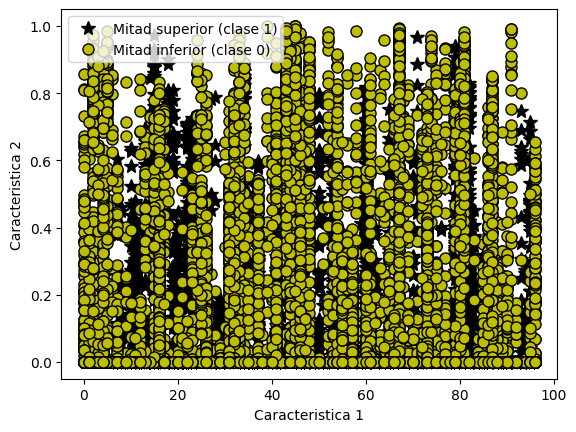

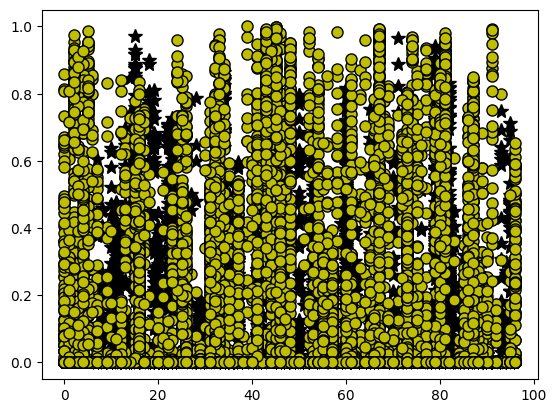

In [21]:
plotData(X_train, y_train)
# adiciona etiquetas para los ejes
pyplot.xlabel('Caracteristica 1')
pyplot.ylabel('Caracteristica 2')
pyplot.legend(['Mitad superior (clase 1)', 'Mitad inferior (clase 0)'])
pass
plotData(X_train_raw, y_train)

Funcion Sigmoidea

In [22]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

Funcion de costo y descenso de gradiente

In [23]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X_train.shape
X_train = np.concatenate([np.ones((m, 1)), X_train], axis=1)

m_test = X_test.shape[0]
X_test = np.concatenate([np.ones((m_test, 1)), X_test], axis=1)

In [24]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [25]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

theta calculado por el descenso por el gradiente: [-1.84191250e-03 -2.52050669e-03 -1.08577622e-03 -2.13851690e-04
  8.44548242e-04  2.19462011e-03  4.07704739e-03  1.10521161e-03
  1.39255461e-03 -2.20887185e-05 -1.93149471e-03 -1.58198928e-04
 -7.22918342e-04  1.85872433e-04  2.41962944e-04 -4.91159385e-05
  1.38394120e-03 -4.31387444e-05  7.72187697e-04  5.89388466e-05
  8.20968474e-04  4.07865267e-04 -3.18395296e-04  8.20577529e-05
 -5.08875462e-04 -1.03489361e-03 -1.71559057e-03 -2.13836014e-03
  3.44562132e-05  1.39053595e-04  4.68388718e-04  1.33698658e-03
 -2.47271534e-04 -3.74284920e-04 -1.49272462e-03 -2.08225195e-03
 -3.50067433e-03 -3.13659752e-03 -1.07401099e-03  5.91681399e-04
  3.73818567e-04 -6.58987586e-04 -3.04432995e-04 -4.83241438e-04
 -1.52210249e-03 -2.50208695e-03 -3.82870971e-03 -2.52946667e-03
 -1.49103376e-03 -5.97647936e-04 -9.62489411e-04  2.54554326e-04
 -3.34132199e-04  5.30406751e-04 -6.73167083e-04 -3.79997425e-03
 -4.89566495e-03 -3.44379767e-03 -3.6049

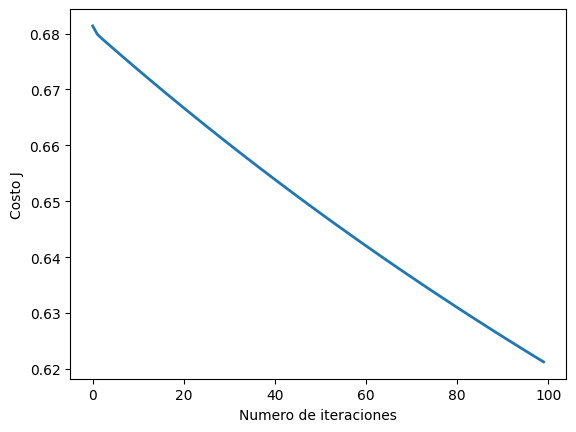

In [26]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 100

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(n + 1)
theta, J_history = descensoGradiente(theta, X_train, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

In [ ]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

In [30]:
def plotDecisionBoundary(plotData, theta, X, y):
    """
    Grafica los puntos X y Y en una nueva figura con un limite de desicion definido por theta.
    Grafica los puntos con * para los ejemplos positivos y con o para los ejemplos negativos.

    Parametros:
    ----------
    plotData : func
        A function reference for plotting the X, y data.

    theta : array_like
        Parametros para la regresion logistica. Un vecto de la forma (n+1, ).

    X : array_like
        Data set de entrada. Se supone que X es una de las siguientes:
            1) Matriz Mx3, donde la primera columna es una columna de unos para intercepción.
            2) Matriz MxN, N> 3, donde la primera columna son todos unos.

    y : array_like
        Vector de datos de etiquetas de la forma (m, ).
    """
    # hacer que theta sera un arreglo numpy
    theta = np.array(theta)

    # Graficar los datos (recordar que la primera columna en X es la intercepción)
    plotData(X[:, 1:3], y)

    if X.shape[1] <= 3:
        # Solo se requieren 2 puntos para definir una linea, para lo cual se eligen dos puntos finales
        plot_x = np.array([np.min(X[:, 1]) - 2, np.max(X[:, 1]) + 2])

        # Calcular la línea límite de decisión
        plot_y = (-1. / theta[2]) * (theta[1] * plot_x + theta[0])

        pyplot.plot(plot_x, plot_y)
        pyplot.legend(['Mitad superior', 'Mitad inferior', 'Limite de decision'])

    else:
        # Con N>3 no se puede graficar el limite real en todas las dimensiones.
        # Se proyecta sobre las 2 primeras caracteristicas para visualizar la separacion.
        x1_vals = np.linspace(X[:, 1].min(), X[:, 1].max(), 200)
        x2_vals = np.linspace(X[:, 2].min(), X[:, 2].max(), 200)

        xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

        # Construir matriz de puntos de la grilla con bias=1 y resto de features en 0
        grid = np.zeros((xx1.size, X.shape[1]))
        grid[:, 0] = 1               # termino de intercepcion
        grid[:, 1] = xx1.ravel()     # caracteristica 1
        grid[:, 2] = xx2.ravel()     # caracteristica 2

        z = sigmoid(grid.dot(theta)).reshape(xx1.shape)

        pyplot.contour(xx1, xx2, z, levels=[0.5], linewidths=2, colors='g')
        pyplot.contourf(xx1, xx2, z, levels=[0, 0.5, 1], cmap='Greens', alpha=0.4)
        pyplot.legend(['Mitad superior', 'Mitad inferior'])
        pyplot.xlabel('Caracteristica 1')
        pyplot.ylabel('Caracteristica 2')

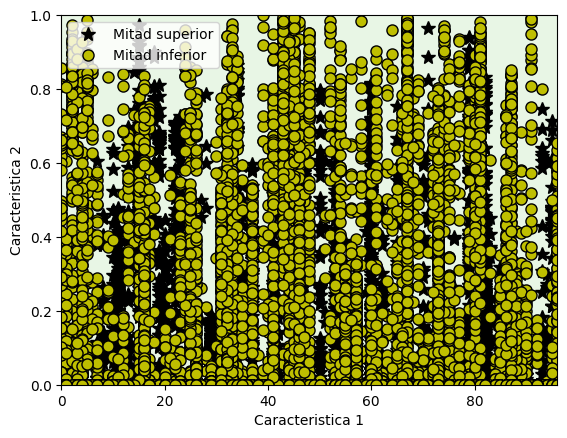

In [31]:
# Graficar limites
plotDecisionBoundary(plotData, theta, X_train, y_train)

Parámetros de aprendizaje

In [27]:
# Establecer las opciones para optimize.minimize
options= {'maxiter': 1000}

# revisar la documentacion de scipy's optimize.minimize para mayor descripcion de los parametros
# La funcion devuelve un objeto `OptimizeResult`
# Se utiliza el algoritmo de Newton truncado para la optimización.
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_train, y_train),
                        jac=True,
                        method='TNC',
                        options=options)

# la propiedad fun del objeto devuelto por `OptimizeResult`
# contiene el valor del costFunction de un theta optimizado
cost = res.fun

# Theta optimizada esta en la propiedad x
theta = res.x

# Imprimir theta en la pantalla
print('Costo con un valor de theta encontrado por optimize.minimize: {:.3f}'.format(cost))
print('theta (primeros 4 valores):')
print('\t[{:.3f}, {:.3f}, {:.3f}, {:.3f}]'.format(*theta[:4]))

/tmp/ipykernel_535/2479943343.py:7: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,
/tmp/ipykernel_535/3547816735.py:7: RuntimeWarning: divide by zero encountered in log
  J    = (-1.0 / m) * (y.dot(np.log(h)) + (1 - y).dot(np.log(1 - h)))


Costo con un valor de theta encontrado por optimize.minimize: 0.033
theta (primeros 4 valores):
	[-1.955, 0.003, -1.276, -0.896]


Evaluacion de la regresion binaria

In [28]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 o 1 mediante regresión logística aprendida.
    Calcula las predicciones para X usando un umbral en 0.5 (es decir, si sigmoide (theta.T * x)> = 0.5, predice 1)

    Parametros
    ----------
    theta : array_like
        Parametros para regresion logistica. Un vecto de la forma (n+1, ).

    X : array_like
        Datos utilizados para el calculo de las predicciones.
        La fila es el numero de los puntos para calcular las predicciones,
        y las columnas con el numero de caracteristicas.

    Devuelve
    -------
    p : array_like
        Predicciones y 0 o 1 para cada fila en X.
    """
    m = X.shape[0] # Numero de ejemplo de entrenamiento

    p = np.zeros(m)

    p = np.round(sigmoid(X.dot(theta.T)))
    return p

In [29]:
# Prediccion sobre el conjunto de entrenamiento
p_train = predict(theta, X_train)
print('Precision de entrenamiento: {:.2f} %'.format(np.mean(p_train == y_train) * 100))

# Prediccion sobre el conjunto de prueba (datos no vistos durante el entrenamiento)
p_test = predict(theta, X_test)
print('Precision de prueba:        {:.2f} %'.format(np.mean(p_test == y_test) * 100))

# Evaluacion de clasificacion binaria
# Verdaderos positivos, verdaderos negativos, falsos positivos, falsos negativos
TP = np.sum((p_test == 1) & (y_test == 1))
TN = np.sum((p_test == 0) & (y_test == 0))
FP = np.sum((p_test == 1) & (y_test == 0))
FN = np.sum((p_test == 0) & (y_test == 1))

precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0
f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print('\nMatriz de confusion (conjunto de prueba):')
print('                 Predicho 0   Predicho 1')
print('  Real 0        {:>10,}   {:>10,}'.format(TN, FP))
print('  Real 1        {:>10,}   {:>10,}'.format(FN, TP))
print('\nPrecision (Precision): {:.4f}'.format(precision))
print('Recall:                {:.4f}'.format(recall))
print('F1-Score:              {:.4f}'.format(f1))

Precision de entrenamiento: 98.92 %
Precision de prueba:        98.85 %

Matriz de confusion (conjunto de prueba):
                 Predicho 0   Predicho 1
  Real 0             6,099           73
  Real 1                50        4,478

Precision (Precision): 0.9840
Recall:                0.9890
F1-Score:              0.9865
